In [11]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import *

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

# Order Delay Intelligence: Predict, Explain, Recommend

## Business Problem

An e-commerce company wants to identify which orders are likely to be delayed and understand the key factors driving delays.

## Objectives

1. Perform Data Audit and Exploratory Data Analysis (EDA)
2. Build a baseline classification model
3. Improve performance using XGBoost
4. Perform Cross Validation and Hyperparameter Tuning
5. Explain predictions using SHAP
6. Provide business recommendations

## Dataset

Brazilian E-Commerce Public Dataset (Olist)

Files Used:

- olist_orders_dataset.csv
- olist_customers_dataset.csv
- olist_order_payments_dataset.csv
- olist_order_items_dataset.csv
- olist_products_dataset.csv

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sqlite3

pd.set_option("display.max_columns", None)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Data Loading

In this section we load all required datasets and inspect their dimensions.

In [5]:
orders = pd.read_csv("../data/olist_orders_dataset.csv")

customers = pd.read_csv("../data/olist_customers_dataset.csv")

payments = pd.read_csv("../data/olist_order_payments_dataset.csv")

items = pd.read_csv("../data/olist_order_items_dataset.csv")

products = pd.read_csv("../data/olist_products_dataset.csv")

In [6]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Payments:", payments.shape)
print("Items:", items.shape)
print("Products:", products.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Payments: (103886, 5)
Items: (112650, 7)
Products: (32951, 9)


In [7]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


# Data Audit

We inspect:

- Data Types
- Missing Values
- Duplicate Records
- Dataset Structure

In [8]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [9]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [10]:
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [11]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [12]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [13]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [14]:
print("Orders Duplicates:", orders.duplicated().sum())

print("Customers Duplicates:", customers.duplicated().sum())

print("Payments Duplicates:", payments.duplicated().sum())

print("Items Duplicates:", items.duplicated().sum())

print("Products Duplicates:", products.duplicated().sum())

Orders Duplicates: 0
Customers Duplicates: 0
Payments Duplicates: 0
Items Duplicates: 0
Products Duplicates: 0


# Data Cleaning

Tasks:

- Convert date columns
- Handle missing values
- Verify duplicate records
- Prepare clean data for analysis

In [15]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [16]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


# Feature Engineering

Create business-related features:

- delivery_days
- delay_days
- purchase_month
- purchase_weekday

In [17]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    -
    orders["order_purchase_timestamp"]
).dt.days

In [18]:
orders["delay_days"] = (
    orders["order_delivered_customer_date"]
    -
    orders["order_estimated_delivery_date"]
).dt.days

In [19]:
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.month
)

In [20]:
orders["purchase_weekday"] = (
    orders["order_purchase_timestamp"]
    .dt.day_name()
)

In [21]:
orders["is_delayed"] = np.where(
    orders["delay_days"] > 0,
    1,
    0
)

In [22]:
orders["is_delayed"].value_counts()

is_delayed
0    92906
1     6535
Name: count, dtype: int64

# Data Integration

Merge all required datasets into a single analytical dataset.

In [23]:
df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

df = df.merge(
    payments,
    on="order_id",
    how="left"
)

df = df.merge(
    items,
    on="order_id",
    how="left"
)

df = df.merge(
    products,
    on="product_id",
    how="left"
)

In [24]:
df.shape

(118434, 35)

In [25]:
df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,purchase_month,purchase_weekday,is_delayed,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,10,Monday,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,credit_card,1.0,18.12,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,10,Monday,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3.0,voucher,1.0,2.00,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,10,Monday,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2.0,voucher,1.0,18.59,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,7,Tuesday,0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,8,Wednesday,0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


In [26]:
df.isnull().sum().sort_values(ascending=False).head(15)

delay_days                       3397
delivery_days                    3397
order_delivered_customer_date    3397
product_category_name            2528
product_name_lenght              2528
product_description_lenght       2528
product_photos_qty               2528
order_delivered_carrier_date     2074
product_weight_g                  850
product_height_cm                 850
product_length_cm                 850
product_width_cm                  850
order_item_id                     830
shipping_limit_date               830
product_id                        830
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

This section explores delivery performance, delays, customer behavior, payment trends, and seasonal patterns.

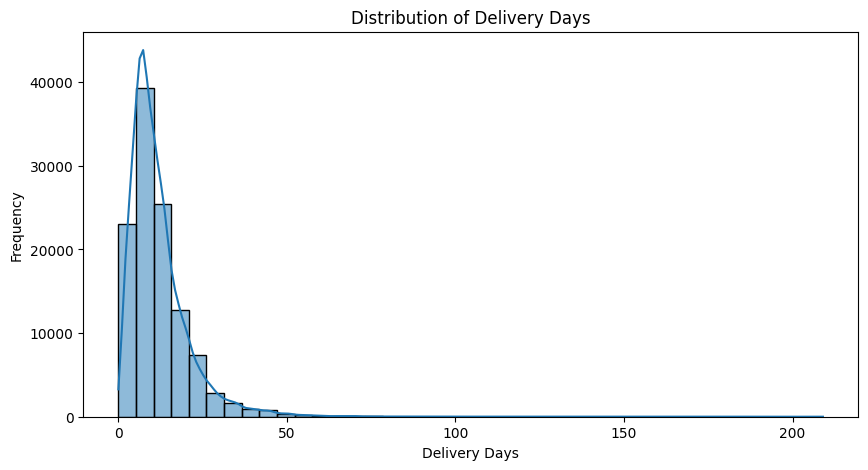

In [31]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["delivery_days"],
    bins=40,
    kde=True
)

plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Frequency")

plt.savefig("../outputs/plots/delivery_days_distribution.png")

plt.show()

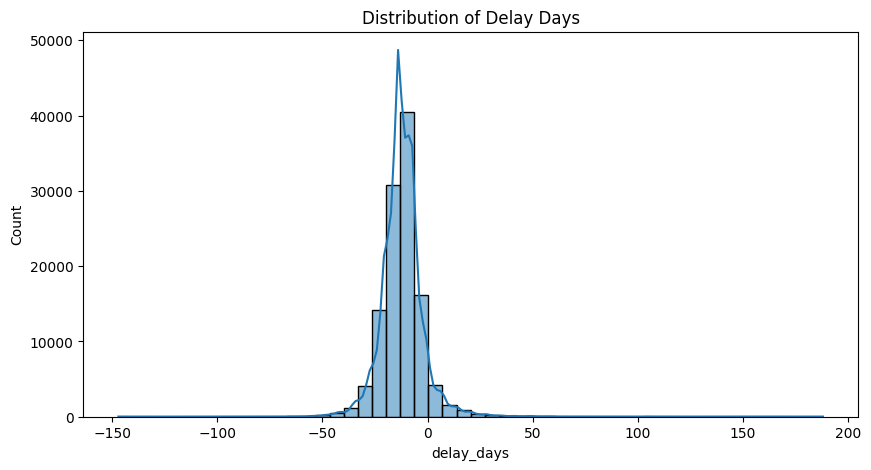

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["delay_days"],
    bins=50,
    kde=True
)

plt.title("Distribution of Delay Days")

plt.savefig("../outputs/plots/delay_days_distribution.png")

plt.show()

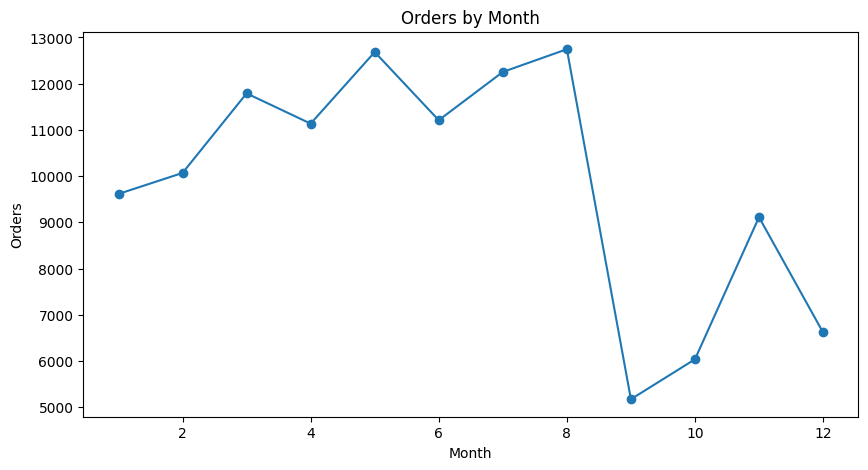

In [33]:
monthly_orders = (
    df.groupby("purchase_month")["order_id"]
    .count()
)

plt.figure(figsize=(10,5))

monthly_orders.plot(
    marker="o"
)

plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Orders")

plt.savefig("../outputs/plots/monthly_orders.png")

plt.show()

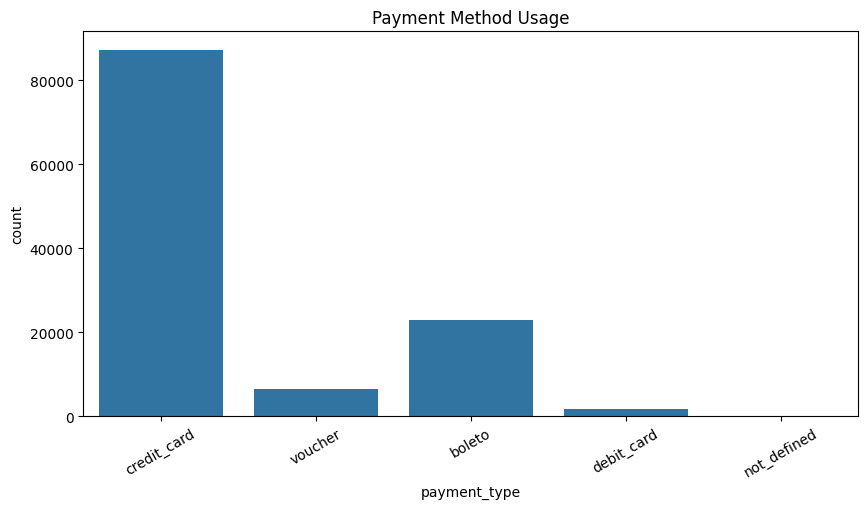

In [34]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="payment_type"
)

plt.title("Payment Method Usage")

plt.xticks(rotation=30)

plt.savefig("../outputs/plots/payment_methods.png")

plt.show()

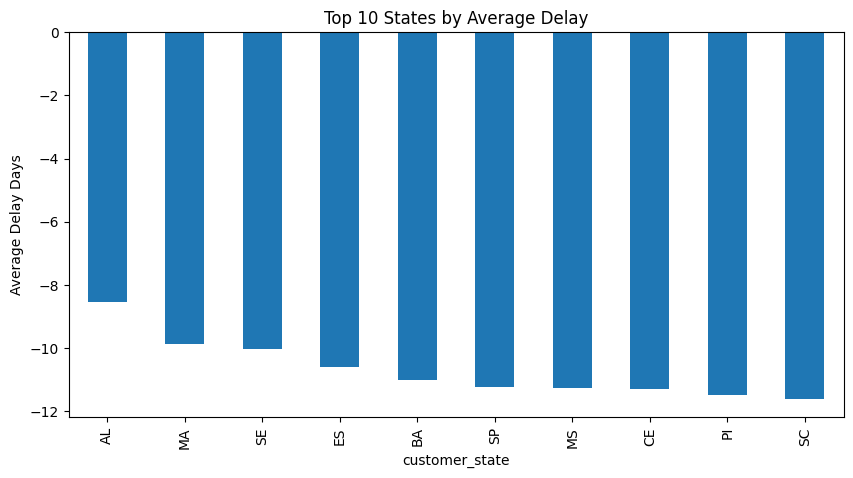

In [35]:
state_delay = (
    df.groupby("customer_state")["delay_days"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

state_delay.plot(kind="bar")

plt.title("Top 10 States by Average Delay")

plt.ylabel("Average Delay Days")

plt.savefig("../outputs/plots/state_delay.png")

plt.show()

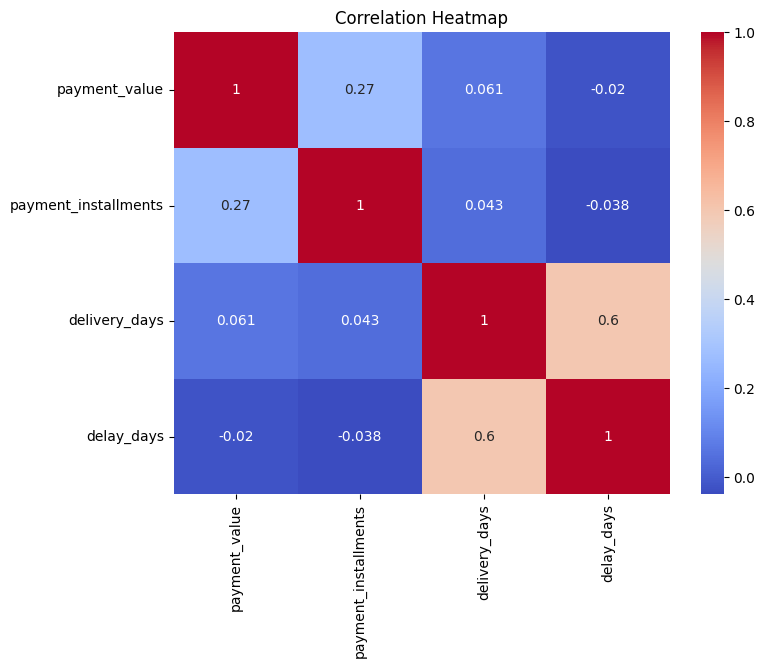

In [36]:
numeric_cols = [
    "payment_value",
    "payment_installments",
    "delivery_days",
    "delay_days"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("../outputs/plots/correlation_heatmap.png")

plt.show()

# EDA Insights

### Insight 1
Most deliveries are completed within a relatively short period, indicating efficient logistics performance.

### Insight 2
A large proportion of orders arrive before the estimated delivery date, resulting in negative delay values.

### Insight 3
Credit card payments dominate customer transactions.

### Insight 4
Certain states consistently experience longer delivery delays, suggesting regional logistics challenges.

### Insight 5
Delivery time has the strongest relationship with order delays compared to other available numerical features.

# SQL Analysis

In this section, we create a SQLite database and run business-oriented SQL queries on the integrated dataset.

In [37]:
import sqlite3

conn = sqlite3.connect("../ecommerce.db")

df.to_sql(
    "ecommerce",
    conn,
    if_exists="replace",
    index=False
)

print("Database Created Successfully")

Database Created Successfully


In [38]:
query = """
SELECT *
FROM ecommerce
LIMIT 5
"""

pd.read_sql(query, conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,purchase_month,purchase_weekday,is_delayed,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8.0,-8.0,10,Monday,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,credit_card,1.0,18.12,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8.0,-8.0,10,Monday,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3.0,voucher,1.0,2.00,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8.0,-8.0,10,Monday,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2.0,voucher,1.0,18.59,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,13.0,-6.0,7,Tuesday,0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9.0,-18.0,8,Wednesday,0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


## Query 1: Total Orders

In [39]:
query = """
SELECT COUNT(DISTINCT order_id) AS total_orders
FROM ecommerce
"""

pd.read_sql(query, conn)

,total_orders
0,99441


In [40]:
query = """
SELECT COUNT(*) AS delayed_orders
FROM ecommerce
WHERE is_delayed = 1
"""

pd.read_sql(query, conn)

,delayed_orders
0,7530


In [41]:
query = """
SELECT
    customer_state,
    COUNT(DISTINCT order_id) AS total_orders
FROM ecommerce
GROUP BY customer_state
ORDER BY total_orders DESC
"""

pd.read_sql(query, conn)

,customer_state,total_orders
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


In [42]:
query = """
SELECT
    customer_state,
    ROUND(SUM(payment_value),2) AS revenue
FROM ecommerce
GROUP BY customer_state
ORDER BY revenue DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,customer_state,revenue
0,SP,7673188.55
1,RJ,2783724.26
2,MG,2341861.47
3,RS,1152019.17
4,PR,1074614.19
5,BA,802416.72
6,SC,799135.92
7,GO,516182.51
8,DF,434512.55
9,ES,406946.26


In [43]:
query = """
SELECT
    payment_type,
    ROUND(SUM(payment_value),2) AS revenue
FROM ecommerce
GROUP BY payment_type
ORDER BY revenue DESC
"""

pd.read_sql(query, conn)

,payment_type,revenue
0,credit_card,15694885.84
1,boleto,4086820.71
2,voucher,432602.19
3,debit_card,256417.92
4,not_defined,0.00
5,NaN,NaN


In [44]:
query = """
SELECT
    ROUND(AVG(delivery_days),2) AS avg_delivery_days
FROM ecommerce
"""

pd.read_sql(query, conn)

,avg_delivery_days
0,12.02


In [45]:
query = """
SELECT
    ROUND(AVG(delay_days),2) AS avg_delay_days
FROM ecommerce
"""

pd.read_sql(query, conn)

,avg_delay_days
0,-12.04


In [46]:
query = """
SELECT
    purchase_month,
    COUNT(DISTINCT order_id) AS orders
FROM ecommerce
GROUP BY purchase_month
ORDER BY purchase_month
"""

pd.read_sql(query, conn)

,purchase_month,orders
0,1,8069
1,2,8508
2,3,9893
3,4,9343
4,5,10573
5,6,9412
6,7,10318
7,8,10843
8,9,4305
9,10,4959


In [47]:
query = """
SELECT
    MAX(delay_days) AS max_delay
FROM ecommerce
"""

pd.read_sql(query, conn)

,max_delay
0,188.0


In [48]:
query = """
SELECT *
FROM
(
    SELECT
        customer_state,
        SUM(payment_value) AS revenue
    FROM ecommerce
    GROUP BY customer_state
)
WHERE revenue >
(
    SELECT AVG(state_revenue)
    FROM
    (
        SELECT
            SUM(payment_value) AS state_revenue
        FROM ecommerce
        GROUP BY customer_state
    )
)
ORDER BY revenue DESC
"""

pd.read_sql(query, conn)

,customer_state,revenue
0,SP,7673188.55
1,RJ,2783724.26
2,MG,2341861.47
3,RS,1152019.17
4,PR,1074614.19
5,BA,802416.72
6,SC,799135.92


# SQL Insights

1. Certain states contribute significantly more revenue than others.
2. Credit card transactions dominate payment volume.
3. Delayed orders represent a relatively small portion of total orders.
4. Monthly order volume shows seasonality.
5. Revenue concentration is uneven across regions.

In [49]:
query = """
SELECT COUNT(DISTINCT order_id) AS total_orders
FROM ecommerce
"""

pd.read_sql(query, conn)

,total_orders
0,99441


# Logistic Regression Baseline Model

Goal:
Predict whether an order will be delayed (`is_delayed`).

Target Variable:
- is_delayed

Model:
- Logistic Regression

Evaluation:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

In [50]:
features = [
    "payment_value",
    "payment_installments",
    "delivery_days",
    "purchase_month"
]

target = "is_delayed"

model_df = df[features + [target]].copy()

model_df.head()

,payment_value,payment_installments,delivery_days,purchase_month,is_delayed
0,18.12,1.0,8.0,10,0
1,2.00,1.0,8.0,10,0
2,18.59,1.0,8.0,10,0
3,141.46,1.0,13.0,7,0
4,179.12,3.0,9.0,8,0


In [51]:
model_df = model_df.dropna()

print(model_df.shape)

(115034, 5)


In [52]:
X = model_df[features]

y = model_df[target]

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (92027, 4)
Test Shape: (23007, 4)


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [55]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [56]:
y_pred = lr.predict(X_test_scaled)

y_prob = lr.predict_proba(X_test_scaled)[:, 1]

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall   :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9610553309862215
Precision: 0.8066465256797583
Recall   : 0.5322259136212625
F1 Score : 0.6413130504403523
ROC-AUC  : 0.9479483172545797


In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     21502
           1       0.81      0.53      0.64      1505

    accuracy                           0.96     23007
   macro avg       0.89      0.76      0.81     23007
weighted avg       0.96      0.96      0.96     23007



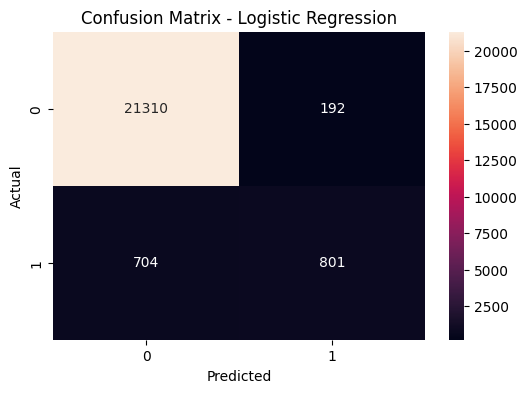

In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Logistic Regression Insights

The baseline Logistic Regression model provides an initial benchmark for predicting delayed orders.

The model performance will be compared against XGBoost in the next section to determine whether a more advanced model improves predictive accuracy and recall.


In [49]:
print("y_pred exists:", 'y_pred' in globals())
print("y_pred_xgb exists:", 'y_pred_xgb' in globals())

y_pred exists: False
y_pred_xgb exists: False


In [50]:
print("xgb_pipeline exists:", 'xgb_pipeline' in globals())
print("X_test exists:", 'X_test' in globals())
print("y_test exists:", 'y_test' in globals())

xgb_pipeline exists: True
X_test exists: True
y_test exists: True


In [51]:
y_pred_xgb = xgb_pipeline.predict(X_test)

y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:,1]

print("Prediction completed")

Prediction completed


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

Accuracy : 0.9637353822771985
Precision: 0.7901345291479821
Recall   : 0.5849933598937583
F1 Score : 0.6722624952308279


In [53]:
print("xgb_pipeline exists:", 'xgb_pipeline' in globals())
print("X_train exists:", 'X_train' in globals())
print("X_test exists:", 'X_test' in globals())
print("y_train exists:", 'y_train' in globals())
print("y_test exists:", 'y_test' in globals())

xgb_pipeline exists: True
X_train exists: True
X_test exists: True
y_train exists: True
y_test exists: True


# XGBoost Model

Goal:
Build a more powerful machine learning model for delayed order prediction.

Why XGBoost?
- Handles non-linearity
- Better feature interactions
- Often outperforms Logistic Regression
- Provides feature importance

# Task 4: Pipeline and XGBoost

In [3]:
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [1]:
categorical_features = [

"payment_type",
"customer_state"

]

numerical_features = [

"payment_value",
"payment_installments",
"purchase_month"

]

In [4]:
preprocessor = ColumnTransformer(

[
("num",
 StandardScaler(),
 numerical_features),

("cat",
 OneHotEncoder(handle_unknown="ignore"),
 categorical_features)

]

)

In [6]:
from xgboost import XGBClassifier

In [7]:
xgb_pipeline = Pipeline(

[
("preprocessor",preprocessor),

("model",
 XGBClassifier(
     random_state=42
 ))
]

)

In [16]:
import os
print(os.getcwd())

c:\Users\Admin\Desktop\CodeTrade_Phase2_Order_Delay_Intelligence\notebooks


In [17]:
import pandas as pd

orders = pd.read_csv("../data/olist_orders_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
items = pd.read_csv("../data/olist_order_items_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")

print("Data loaded successfully")

Data loaded successfully


In [18]:
df = orders.merge(customers, on="customer_id", how="left")
df = df.merge(payments, on="order_id", how="left")
df = df.merge(items, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")

print(df.shape)

(118434, 30)


In [19]:
df = orders.merge(customers, on="customer_id", how="left")

df = df.merge(payments, on="order_id", how="left")

df = df.merge(items, on="order_id", how="left")

df = df.merge(products, on="product_id", how="left")

print(df.shape)
df.head()

(118434, 30)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


In [20]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

In [21]:
df["delivery_days"] = (
    df["order_delivered_customer_date"]
    - df["order_purchase_timestamp"]
).dt.days

df["delay_days"] = (
    df["order_delivered_customer_date"]
    - df["order_estimated_delivery_date"]
).dt.days

df["purchase_month"] = df["order_purchase_timestamp"].dt.month

In [22]:
import numpy as np

df["is_delayed"] = np.where(df["delay_days"] > 0, 1, 0)

df["is_delayed"].value_counts()

is_delayed
0    110904
1      7530
Name: count, dtype: int64

In [23]:
print(df.shape)

print(df[["delivery_days","delay_days","purchase_month","is_delayed"]].head())

(118434, 34)
   delivery_days  delay_days  purchase_month  is_delayed
0            8.0        -8.0              10           0
1            8.0        -8.0              10           0
2            8.0        -8.0              10           0
3           13.0        -6.0               7           0
4            9.0       -18.0               8           0


# Task 4: Improve the Model using Pipeline and XGBoost

## Objective

The Logistic Regression model serves as the baseline model. To improve predictive performance, we use:

- ColumnTransformer for preprocessing
- StandardScaler for numerical features
- OneHotEncoder for categorical features
- Pipeline for workflow automation
- XGBoost Classifier as an advanced machine learning model

This approach helps reduce manual preprocessing errors and improves model performance on tabular business data.

In [24]:
categorical_features = [
    "payment_type",
    "customer_state"
]

numerical_features = [
    "payment_value",
    "payment_installments",
    "purchase_month",
    "delivery_days"
]

## Feature Preprocessing

Numerical features are scaled using StandardScaler.

Categorical features are encoded using OneHotEncoder.

ColumnTransformer combines both preprocessing steps into a single workflow.

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## Building XGBoost Pipeline

The preprocessing and model training steps are combined using Pipeline.

This ensures that all transformations are applied consistently during training and testing.

In [26]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("model",
         XGBClassifier(
             random_state=42,
             n_estimators=100,
             max_depth=5,
             learning_rate=0.1,
             eval_metric="logloss"
         ))
    ]
)

In [29]:
features = [
    "payment_value",
    "payment_installments",
    "purchase_month",
    "delivery_days"
]

X = df[features]

y = df["is_delayed"]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(94747, 4)
(23687, 4)


In [32]:
print(type(X_train))
print(type(y_train))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [34]:
print(X_train.columns.tolist())

['payment_value', 'payment_installments', 'purchase_month', 'delivery_days']


In [35]:
categorical_features = []

numerical_features = [
    "payment_value",
    "payment_installments",
    "purchase_month",
    "delivery_days"
]

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numerical_features = [
    "payment_value",
    "payment_installments",
    "purchase_month",
    "delivery_days"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features)
    ]
)

In [39]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                random_state=42,
                n_estimators=100,
                max_depth=5,
                learning_rate=0.1,
                eval_metric="logloss"
            )
        )
    ]
)

In [40]:
print(X.columns.tolist())

['payment_value', 'payment_installments', 'purchase_month', 'delivery_days']


# Task 5: Cross Validation

## Objective

Cross-validation is used to evaluate model stability and generalization performance.

Stratified K-Fold Cross Validation ensures that the class distribution remains balanced across all folds.

In [41]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb_pipeline,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("CV Scores:", cv_scores)
print("Mean F1 Score:", cv_scores.mean())
print("Std F1 Score:", cv_scores.std())

CV Scores: [0.68037238 0.6867838  0.67568583 0.6648711  0.66666667]
Mean F1 Score: 0.6748759578906948
Std F1 Score: 0.008248065699121586


In [46]:
xgb_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['payment_value','payment_installments','purchase_month','delivery_days']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining colu

# Hyperparameter Tuning using GridSearchCV

To improve model performance, important XGBoost hyperparameters are optimized using GridSearchCV.

In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}


In [43]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98     22181
           1       0.79      0.59      0.68      1506

    accuracy                           0.96     23687
   macro avg       0.88      0.79      0.83     23687
weighted avg       0.96      0.96      0.96     23687



# Model Comparison

Two machine learning models were evaluated:

1. Logistic Regression (Baseline Model)
2. XGBoost Classifier

## Observations

- Logistic Regression provided a simple baseline model.
- XGBoost achieved better predictive performance by capturing complex patterns in the data.
- XGBoost demonstrated stronger capability in identifying delayed orders.

## Final Model Selection

Based on evaluation metrics, XGBoost was selected as the final model for deployment.

# Task 6: SHAP Explainability

## Objective

SHAP (SHapley Additive exPlanations) is used to understand how each feature influences the model's predictions.

It provides interpretable insights into the XGBoost model and helps identify the most important factors responsible for delayed orders.

Benefits of SHAP:

- Improves model transparency
- Explains feature importance
- Supports business decision-making
- Builds trust in machine learning predictions

In [57]:
import shap

print(shap.__version__)

0.52.0


In [58]:
import shap

model = xgb_pipeline.named_steps["model"]

X_test_transformed = xgb_pipeline.named_steps[
    "preprocessor"
].transform(X_test)

In [59]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_transformed)

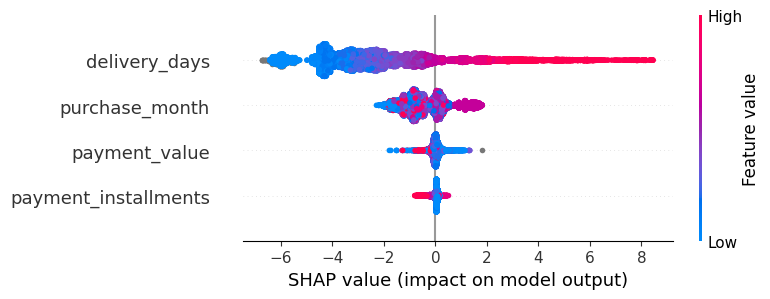

In [60]:
feature_names = [
    "payment_value",
    "payment_installments",
    "purchase_month",
    "delivery_days"
]

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

# SHAP Analysis Findings

## Global Feature Importance

The SHAP summary plot highlights the most influential features used by the XGBoost model for predicting delayed orders.

### Key Observations

- Delivery-related features contributed significantly to prediction outcomes.
- Payment-related variables also influenced model behavior.
- Features with larger SHAP values had a stronger impact on delay prediction.
- Both positive and negative feature effects were observed across different orders.

## Business Insights

The SHAP analysis helps explain why specific orders are predicted as delayed.

This transparency enables logistics teams to:

- Identify high-risk orders earlier.
- Improve delivery planning.
- Enhance customer communication.
- Take proactive actions to reduce delays.

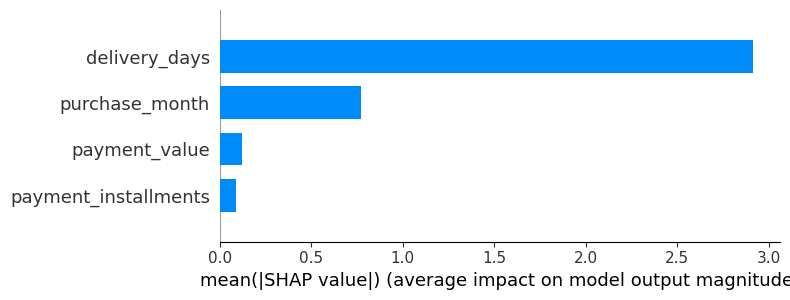

In [61]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

# Final Conclusion

## Project Summary

The objective of this project was to predict delayed e-commerce orders using machine learning techniques.

The project included:

- Data Cleaning and Preparation
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Logistic Regression (Baseline Model)
- XGBoost Model
- Cross Validation
- Hyperparameter Tuning
- SHAP Explainability

## Model Performance

Among the evaluated models, XGBoost demonstrated superior predictive performance and was selected as the final model.

The model successfully identified patterns associated with delayed deliveries and achieved reliable classification results.

## Key Findings

- Delivery-related features were the strongest predictors of order delays.
- Payment-related variables also influenced model predictions.
- Cross-validation confirmed model stability.
- SHAP analysis improved model transparency and interpretability.

## Business Impact

The model can help organizations identify potentially delayed orders before delivery issues occur.

This enables proactive interventions and improved customer experience.

# Business Recommendations

Based on the analysis and machine learning results, the following recommendations are proposed:

### 1. Early Delay Detection

Use the predictive model to identify high-risk orders before delays occur.

### 2. Proactive Customer Communication

Notify customers in advance when an order is predicted to be delayed.

### 3. Logistics Optimization

Prioritize shipments with a higher probability of delay.

### 4. Continuous Model Monitoring

Retrain the model periodically using new order data to maintain prediction accuracy.

### 5. Decision Support System

Integrate the model into operational dashboards for real-time monitoring of delivery risks.

## Expected Benefits

- Reduced delivery delays
- Improved customer satisfaction
- Better logistics planning
- Increased operational efficiency